In [3]:
import argparse
import os
parser = argparse.ArgumentParser()
parser.add_argument('--cache_dir', type=str, default='./cache')
args = parser.parse_known_args()[0]
if not os.path.exists(args.cache_dir):
    os.makedirs(args.cache_dir)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cache directory to prevent re downloading

In [5]:
import fastf1
fastf1.Cache.enable_cache(args.cache_dir)

### 1. Load the data

Loaded the data for the Monaco Grand Prix 2023

In [6]:
session = fastf1.get_session(2023,'Monaco','R')
session.load()
laps=session.laps

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']


In [7]:
laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:27.435000,VER,1,0 days 00:01:24.238000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:37.420000,...,True,Red Bull Racing,0 days 01:02:02.950000,2023-05-28 13:03:03.927,12,1.0,False,,False,False
1,0 days 01:04:46.802000,VER,1,0 days 00:01:19.367000,2.0,1.0,NaT,NaT,0 days 00:00:20.954000,0 days 00:00:37.366000,...,True,Red Bull Racing,0 days 01:03:27.435000,2023-05-28 13:04:28.412,1,1.0,False,,False,True
2,0 days 01:06:05.876000,VER,1,0 days 00:01:19.074000,3.0,1.0,NaT,NaT,0 days 00:00:20.854000,0 days 00:00:37.288000,...,True,Red Bull Racing,0 days 01:04:46.802000,2023-05-28 13:05:47.779,1,1.0,False,,False,True
3,0 days 01:07:24.005000,VER,1,0 days 00:01:18.129000,4.0,1.0,NaT,NaT,0 days 00:00:20.835000,0 days 00:00:36.637000,...,True,Red Bull Racing,0 days 01:06:05.876000,2023-05-28 13:07:06.853,1,1.0,False,,False,True
4,0 days 01:08:42.024000,VER,1,0 days 00:01:18.019000,5.0,1.0,NaT,NaT,0 days 00:00:20.745000,0 days 00:00:36.734000,...,True,Red Bull Racing,0 days 01:07:24.005000,2023-05-28 13:08:24.982,1,1.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1510,0 days 02:45:26.408000,PIA,81,0 days 00:01:27.443000,73.0,2.0,NaT,NaT,0 days 00:00:23.295000,0 days 00:00:42.212000,...,True,McLaren,0 days 02:43:58.965000,2023-05-28 14:44:59.942,1,10.0,False,,False,True
1511,0 days 02:46:52.593000,PIA,81,0 days 00:01:26.185000,74.0,2.0,NaT,NaT,0 days 00:00:22.381000,0 days 00:00:42.112000,...,True,McLaren,0 days 02:45:26.408000,2023-05-28 14:46:27.385,1,10.0,False,,False,True
1512,0 days 02:48:18.736000,PIA,81,0 days 00:01:26.143000,75.0,2.0,NaT,NaT,0 days 00:00:22.061000,0 days 00:00:42.272000,...,True,McLaren,0 days 02:46:52.593000,2023-05-28 14:47:53.570,1,10.0,False,,False,True
1513,0 days 02:49:44.351000,PIA,81,0 days 00:01:25.615000,76.0,2.0,NaT,NaT,0 days 00:00:21.991000,0 days 00:00:41.496000,...,True,McLaren,0 days 02:48:18.736000,2023-05-28 14:49:19.713,1,10.0,False,,False,True


### 2. Cleaning data

The session.laps method extracts the lap by lap data as a pandas dataframe, one row per lap and driver, alongside additional factors like drivernumber, lap time, pit out time, pit in time and more

In [8]:
fast_laps = laps.pick_quicklaps()

Filtering out laps that may be outliers compared to a driver's best laps. Now, remove the laps where the driver did a pitstop by filtering the laps where PitInTime and PitOutTime were logged.

In [9]:
fast_laps = fast_laps[(fast_laps['PitOutTime'].isna()) & (fast_laps['PitInTime'].isna())]

In [10]:
# make a copy to work on
best_laps = fast_laps.copy()

### 3. Working on the data

In [11]:
# making a column which gives the lap time as a plain float
best_laps['Time(s)'] = best_laps['LapTime'].dt.total_seconds()

#select required columns for analysis
data_stint = best_laps[['Driver','Stint','Compound','TyreLife','Time(s)']]
print(data_stint)

     Driver  Stint Compound  TyreLife  Time(s)
1       VER    1.0   MEDIUM       2.0   79.367
2       VER    1.0   MEDIUM       3.0   79.074
3       VER    1.0   MEDIUM       4.0   78.129
4       VER    1.0   MEDIUM       5.0   78.019
5       VER    1.0   MEDIUM       6.0   77.640
...     ...    ...      ...       ...      ...
1482    PIA    1.0     HARD      45.0   77.846
1483    PIA    1.0     HARD      46.0   77.516
1484    PIA    1.0     HARD      47.0   77.513
1485    PIA    1.0     HARD      48.0   78.001
1487    PIA    1.0     HARD      50.0   78.201

[934 rows x 5 columns]


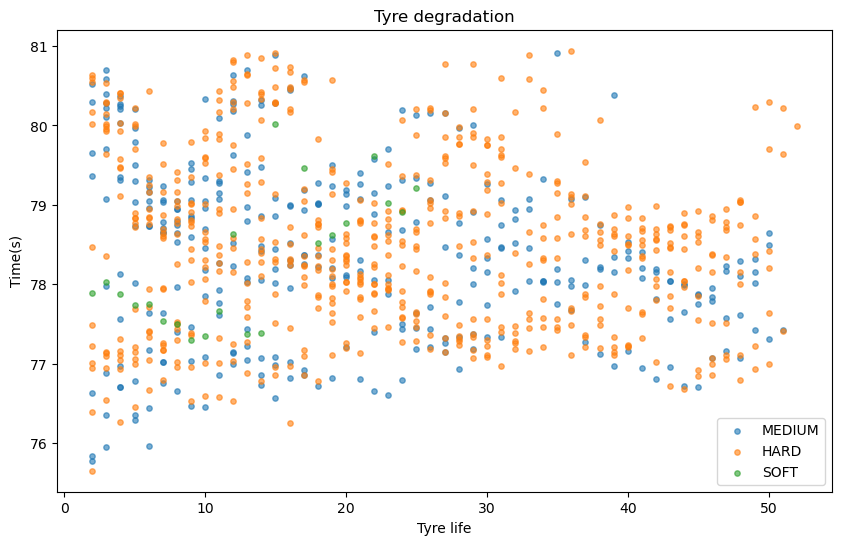

In [12]:
#plotting
fig,ax = plt.subplots(figsize=(10,6))

for compound in data_stint['Compound'].unique():
    compound_data = data_stint[data_stint['Compound']==compound]
    ax.scatter(compound_data['TyreLife'],compound_data['Time(s)'],label = compound, alpha = .6,s=15)
ax.set_xlabel('Tyre life');ax.set_ylabel('Time(s)');ax.set_title('Tyre degradation');ax.legend()
plt.show()

#### Making the degradation model

Fit the lap time and tyre life data into a linear regression model to calculate degradation rate.

In [13]:
#making a regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import linregress

results=[]
for compound in data_stint['Compound'].unique():
    compound_data = data_stint[data_stint['Compound']==compound].dropna(subset=['TyreLife','Time(s)'])
    if len(compound_data) > 6:
        linear_model = LinearRegression()
        linear_model.fit(
            compound_data['TyreLife'].to_numpy().reshape(-1,1),
            compound_data['Time(s)'].to_numpy()
        )
        slope,intercept = linear_model.coef_.item(),linear_model.intercept_.item()
        results.append({
            'Compound':compound,
            'Degradation(sec/lap)':slope,
            'Intercept':intercept,
            'Laps':len(compound_data)
        })
degradation_dataframe = pd.DataFrame(results)
degradation_dataframe

,Compound,Degradation(sec/lap),Intercept,Laps
0,MEDIUM,-0.015897,78.702211,322
1,HARD,-0.008803,78.693447,590
2,SOFT,0.079457,77.245221,22


Normally, lap times get slower as tyre age increases, that is, degraded tyres slow down the car( as seen with the soft compound). However, with the data we can spot that lap times improve with time for medium and hard compounds. This can be attributed to the factors of decrease in fuel and track evolution, which may be decreasing the significance of tyre wear in the model.

#### Investigating further

Even though the soft compound showed degradation, it was used far too less compared to the other compounds. Going deeper, we want to check the drivers who used the soft compound, since pooling different drivers and stints into one generalised regression model can produce outliers. This is true for the other compounds as well.

In [14]:
data_soft = data_stint[data_stint['Compound']=='SOFT'].dropna(subset=['TyreLife','Time(s)'])

print(data_soft[['Driver','Stint','TyreLife','Time(s)']].sort_values('TyreLife'))

    Driver  Stint  TyreLife  Time(s)
466    SAR    3.0       2.0   77.894
467    SAR    3.0       3.0   78.033
468    SAR    3.0       4.0   77.875
469    SAR    3.0       5.0   77.740
470    SAR    3.0       6.0   77.753
471    SAR    3.0       7.0   77.535
472    SAR    3.0       8.0   77.493
473    SAR    3.0       9.0   77.302
474    SAR    3.0      10.0   77.344
475    SAR    3.0      11.0   77.666
476    SAR    3.0      12.0   78.638
477    SAR    3.0      13.0   77.372
478    SAR    3.0      14.0   77.383
479    SAR    3.0      15.0   80.017
481    SAR    3.0      17.0   79.469
482    SAR    3.0      18.0   78.519
483    SAR    3.0      19.0   78.625
484    SAR    3.0      20.0   78.773
486    SAR    3.0      22.0   79.618
487    SAR    3.0      23.0   79.028
488    SAR    3.0      24.0   78.910
489    SAR    3.0      25.0   79.212


We can see that only one driver used the soft compound for a single stint, thus showing normal degradation.

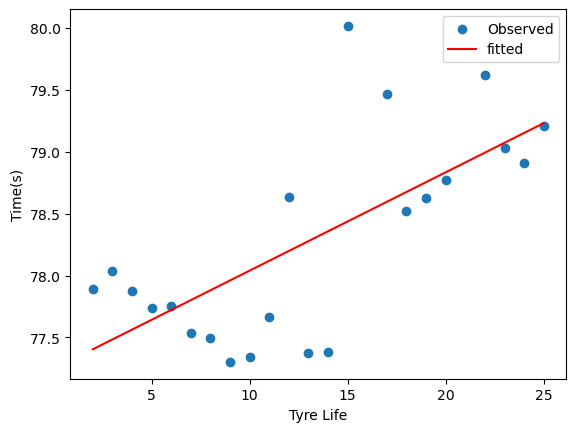

In [15]:
#generating the scatter plot
plt.scatter(data_soft['TyreLife'],data_soft['Time(s)'],label='Observed')
x = np.linspace(data_soft['TyreLife'].min(),data_soft['TyreLife'].max(),100)
y = degradation_dataframe['Degradation(sec/lap)'][2]*x + degradation_dataframe['Intercept'][2]
plt.plot(x,y,color='red',label='fitted')
plt.xlabel('Tyre Life');plt.ylabel('Time(s)');plt.legend()
plt.show()

Given this is Sargeant's 3rd stint, it can be assumed that he switched to softs as a late-race gamble for a better final position

Check if there was rain while the race was ongoing. If this stint was done on a wet track that gradually dried afterwards (after the rain), there is a chance that lap times would be much better independent of tire wear

In [16]:
weather = session.weather_data
sar_laps = laps.pick_drivers('SAR')
stint = sar_laps[sar_laps['Stint']==3]

print(stint[['LapNumber','Time']])

     LapNumber                   Time
465       24.0 0 days 01:35:03.273000
466       25.0 0 days 01:36:21.167000
467       26.0 0 days 01:37:39.200000
468       27.0 0 days 01:38:57.075000
469       28.0 0 days 01:40:14.815000
470       29.0 0 days 01:41:32.568000
471       30.0 0 days 01:42:50.103000
472       31.0 0 days 01:44:07.596000
473       32.0 0 days 01:45:24.898000
474       33.0 0 days 01:46:42.242000
475       34.0 0 days 01:47:59.908000
476       35.0 0 days 01:49:18.546000
477       36.0 0 days 01:50:35.918000
478       37.0 0 days 01:51:53.301000
479       38.0 0 days 01:53:13.318000
480       39.0 0 days 01:54:34.353000
481       40.0 0 days 01:55:53.822000
482       41.0 0 days 01:57:12.341000
483       42.0 0 days 01:58:30.966000
484       43.0 0 days 01:59:49.739000
485       44.0 0 days 02:01:11.864000
486       45.0 0 days 02:02:31.482000
487       46.0 0 days 02:03:50.510000
488       47.0 0 days 02:05:09.420000
489       48.0 0 days 02:06:28.632000
490       49

In [17]:
pd.set_option('display.max_rows',None)
print(weather[['Time','Rainfall','TrackTemp']])
pd.reset_option('display.max_rows')

                      Time  Rainfall  TrackTemp
0   0 days 00:00:42.422000     False       47.4
1   0 days 00:01:42.421000     False       48.2
2   0 days 00:02:42.419000     False       48.2
3   0 days 00:03:42.418000     False       48.3
4   0 days 00:04:42.433000     False       48.3
5   0 days 00:05:42.432000     False       47.4
6   0 days 00:06:42.446000     False       47.2
7   0 days 00:07:42.430000     False       48.3
8   0 days 00:08:42.429000     False       48.3
9   0 days 00:09:42.428000     False       47.2
10  0 days 00:10:42.427000     False       47.0
11  0 days 00:11:42.441000     False       47.3
12  0 days 00:12:42.456000     False       47.3
13  0 days 00:13:42.470000     False       47.0
14  0 days 00:14:42.469000     False       47.0
15  0 days 00:15:42.468000     False       47.5
16  0 days 00:16:42.467000     False       47.6
17  0 days 00:17:42.497000     False       47.3
18  0 days 00:18:42.496000     False       47.8
19  0 days 00:19:42.511000     False    

It indeed rained while the race was going on, now it has to be checked whether Sargeant switched to intermediate or wet when the rain worsened, which would confirm that he was forced off softs and the higher lap times would be due to rain and not tyre age.

In [18]:
print(sar_laps[['LapNumber','Stint','Compound','Time']])

     LapNumber  Stint      Compound                   Time
442        1.0    1.0        MEDIUM 0 days 01:03:40.886000
443        2.0    1.0        MEDIUM 0 days 01:05:00.544000
444        3.0    1.0        MEDIUM 0 days 01:06:20.763000
445        4.0    1.0        MEDIUM 0 days 01:07:41.009000
446        5.0    1.0        MEDIUM 0 days 01:09:01.223000
..         ...    ...           ...                    ...
513       72.0    4.0  INTERMEDIATE 0 days 02:46:16.025000
514       73.0    4.0  INTERMEDIATE 0 days 02:47:43.162000
515       74.0    4.0  INTERMEDIATE 0 days 02:49:11.116000
516       75.0    4.0  INTERMEDIATE 0 days 02:50:39.084000
517       76.0    4.0  INTERMEDIATE 0 days 02:52:08.160000

[76 rows x 4 columns]


The occurrence of the intermediate compound is definitive proof that Sargeant was racing on softs during rain, and was pushing it as long as possible. However, as the rain worsened, he switched to the intermediate compound.

### 4. Analysing drivers

In [19]:
#Only medium and hard compounds included
compounds = best_laps[best_laps['Compound'].isin(['MEDIUM','HARD'])].copy()
# now analyse each driver by fitting a linear regression model
driver_results=[]
for driver in compounds['Driver'].unique():
    for compound in ['MEDIUM','HARD']:
        extract = compounds[(
            compounds['Driver']==driver) & (
                compounds['Compound']==compound
            )].dropna(subset=['TyreLife','Time(s)'])

        #minimum 6 laps completed with a compound
        if len(extract)>6:
            linear_model = linregress(
                extract['TyreLife'],
                extract['Time(s)']
            )

            slope,intercept = linear_model.slope,linear_model.intercept
            driver_results.append({
                'Driver':driver,
                'Compound':compound,
                'Degradation(sec/lap)':slope,
                'Intercept':intercept,
                'StdErr':linear_model.stderr,
                f'$R^2$':linear_model.rvalue**2,
                'p-value':linear_model.pvalue,
                'Laps':len(extract)
            })

driver_degradation_dataframe = pd.DataFrame(driver_results)
driver_degradation_dataframe

,Driver,Compound,Degradation(sec/lap),Intercept,StdErr,$R^2$,p-value,Laps
0,VER,MEDIUM,-0.009176,77.650195,0.006624,0.038442,1.723732e-01,50
1,GAS,HARD,-0.048918,79.240008,0.005886,0.616313,1.727647e-10,45
2,PER,MEDIUM,0.075497,76.465710,0.036871,0.258917,6.314236e-02,14
3,PER,HARD,0.079210,77.546423,0.025217,0.267632,4.053917e-03,29
4,ALO,HARD,-0.014152,77.999296,0.006880,0.081010,4.514234e-02,50
5,LEC,HARD,-0.046726,79.155695,0.006231,0.584335,3.825253e-09,42
6,STR,HARD,-0.023818,79.877517,0.007599,0.182526,3.063743e-03,46
7,SAR,MEDIUM,0.055121,79.516974,0.029751,0.208901,8.674522e-02,15
8,MAG,HARD,-0.024063,79.954671,0.007245,0.193405,1.762298e-03,48
9,DEV,MEDIUM,-0.035583,80.095881,0.007408,0.334053,1.693870e-05,48


Since the p-value of many rows is greater than a significance of 5%, we cannot be confident that there is a degradation trend seen for that driver and compound. These rows have to be flagged so as to work with only the ones where the tyre degradation is significant alongside a minimum of 15 laps.

In [20]:
driver_degradation_dataframe['Reliable'] = (
    (driver_degradation_dataframe['p-value']<.05) &
    (driver_degradation_dataframe['Laps']>15)
)

In [21]:
# comparing the medium and hard compounds side by side
grouped_df = driver_degradation_dataframe.pivot(
    index='Driver',
    columns = 'Compound',
    values=['Degradation(sec/lap)','Laps','Reliable','StdErr'])
grouped_df.columns=[' '.join(col).strip() for col in grouped_df.columns.values]
grouped_df

,Degradation(sec/lap) HARD,Degradation(sec/lap) MEDIUM,Laps HARD,Laps MEDIUM,Reliable HARD,Reliable MEDIUM,StdErr HARD,StdErr MEDIUM
Driver,,,,,,,,
ALB,0.071379,0.053404,30,15,True,False,0.016677,0.039341
ALO,-0.014152,NaN,50,NaN,True,NaN,0.00688,NaN
BOT,-0.023619,NaN,49,NaN,True,NaN,0.007592,NaN
DEV,NaN,-0.035583,NaN,48,NaN,True,NaN,0.007408
GAS,-0.048918,NaN,45,NaN,True,NaN,0.005886,NaN
HAM,0.003623,-0.07738,19,29,False,True,0.033237,0.009085
HUL,0.024176,NaN,42,NaN,True,NaN,0.010099,NaN
LEC,-0.046726,NaN,42,NaN,True,NaN,0.006231,NaN
MAG,-0.024063,NaN,48,NaN,True,NaN,0.007245,NaN


Keep only the drivers whose data is reliable enough for an analysis.

In [22]:
# filter only reliable drivers
reliable_df = driver_degradation_dataframe[driver_degradation_dataframe['Reliable']]
reliable_df = reliable_df.drop(columns=['Reliable','p-value'])
reliable_df.sort_values('Degradation(sec/lap)')

,Driver,Compound,Degradation(sec/lap),Intercept,StdErr,$R^2$,Laps
15,OCO,MEDIUM,-0.079477,79.492863,0.006559,0.839822,30
18,HAM,MEDIUM,-0.077380,79.542085,0.009085,0.728775,29
21,SAI,HARD,-0.076836,79.498378,0.007680,0.775364,31
1,GAS,HARD,-0.048918,79.240008,0.005886,0.616313,45
5,LEC,HARD,-0.046726,79.155695,0.006231,0.584335,42
24,PIA,HARD,-0.044752,79.929319,0.005052,0.635505,47
22,RUS,HARD,-0.036974,78.986374,0.005658,0.476015,49
9,DEV,MEDIUM,-0.035583,80.095881,0.007408,0.334053,48
17,NOR,MEDIUM,-0.035479,79.634444,0.003932,0.644056,47
10,TSU,MEDIUM,-0.029170,79.389944,0.004379,0.491034,48


This list shows the lap time degradation of the drivers for the 2023 Monaco Grand Prix race session ( for whom the data was reliable enough to be analysed), sorted by the most efficient to the least efficient in managing their tyres

Now, we want to see how each driver compares relative to the other drivers

In [34]:
#Comparing the relative degradation
relative_df = driver_degradation_dataframe.copy()
relative_df['Average']=driver_degradation_dataframe.groupby(
    'Compound')['Degradation(sec/lap)'].transform('mean')
relative_df['Relative degradation']=driver_degradation_dataframe[
'Degradation(sec/lap)']-driver_degradation_dataframe['Average']

#apply filter again - only reliable data to be analysed
relative_df = relative_df[relative_df['Reliable']]
relative_df = relative_df.drop(columns=['Reliable','p-value'])
relative_df.sort_values('Relative degradation').head(5)

,Driver,Compound,Degradation(sec/lap),Intercept,StdErr,$R^2$,Laps,Average,Relative degradation
15,OCO,MEDIUM,-0.079477,79.492863,0.006559,0.839822,30,-0.006186,-0.073291
18,HAM,MEDIUM,-0.077380,79.542085,0.009085,0.728775,29,-0.006186,-0.071194
21,SAI,HARD,-0.076836,79.498378,0.007680,0.775364,31,-0.006410,-0.070426
1,GAS,HARD,-0.048918,79.240008,0.005886,0.616313,45,-0.006410,-0.042507
5,LEC,HARD,-0.046726,79.155695,0.006231,0.584335,42,-0.006410,-0.040316


These are the five drivers who were the most efficient in managing their tyre wear. According to calculations, their lap times got faster with increasing tyre age, quite opposite to a normal tyre degradation linear model.

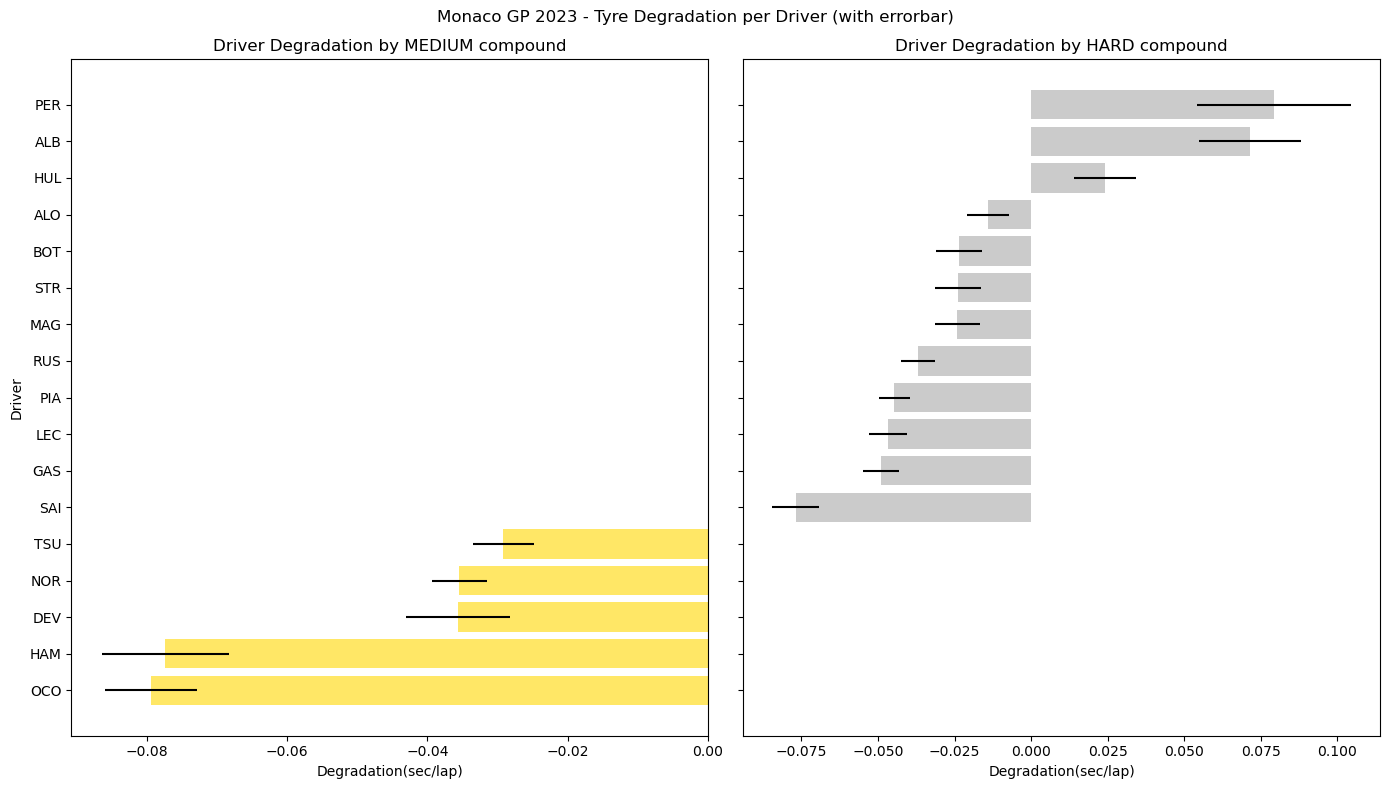

In [40]:
# visualization
fig,ax = plt.subplots(1,2,figsize=(14,8),sharey=True)

for axis,compound in zip(ax,['MEDIUM','HARD']):
    extract = relative_df[relative_df['Compound']==compound].sort_values('Degradation(sec/lap)')
    if compound=='MEDIUM':
        axis.barh(extract['Driver'],extract['Degradation(sec/lap)'],xerr=extract['StdErr'],color='gold',alpha=.6)
    else:
        axis.barh(extract['Driver'],extract['Degradation(sec/lap)'],xerr=extract['StdErr'],color='darkgrey',alpha=.6)
    axis.set_title(f'Driver Degradation by {compound} compound')
    axis.set_xlabel('Degradation(sec/lap)')
ax[0].set_ylabel('Driver')
plt.suptitle('Monaco GP 2023 - Tyre Degradation per Driver (with errorbar)')
plt.tight_layout()
plt.show()

### Conclusion

The tyre degradation for the Monaco Grand Prix 2023 was minimal for almost every driver in the grid using the hard and medium compounds. The degradation for both the compounds (MEDIUM = -0.016 sec/lap and HARD = -0.0088 sec/lap) were found to be negative, indicating strongly that external factors like fuel burn( which makes the car lighter with more laps) and track evolution( gradual increase in overall track grip) have a significant influence on the lap times than tyre wear alone.

*Comparing compounds*
- The average degradation for the hard compound($-6.41*10^{-3}$) was slightly lower than the medium compound($-6.186*10^{-3}$).
- However, despite the hard compound being better, two drivers(Ocon and Hamilton) on mediums showed way better degradation management relative to the grid with atleast 29 laps. Sainz was their equal from the hard compound group.

*Data wrangling and review*
- Only the fastest recorded lap times of each driver was taken into account by the quick_laps method. The method selects laps that are within 107% of the fastest lap in the selected session. Therefore, stints done in rain( which would be slower) or those done with intermediate or hard compounds were excluded, they did not appear in the analysis. Only dry compounds appeared in the analysis.
- Only one driver, Sargeant used the soft compound during the race. This was done in his 3rd stint, most probably as a final surge for a better position. However, this data did not make it into the final analysis since only one driver used it( small sample). Moreover, the stint was done in rainy conditions, where reduction in track grip may have been a bigger factor for increase in lap times instead of tyre degradation, since he switched to intermediates afterwards.
- The error values for some drivers may be higher due to shorter stints done with a particular compound.

*Future scope*
- The tyre degradation model was assumed to be a linear one. Complex models may be more accurate.
- The main assumption of this project was that older tyres may be the dominant factor for worse lap times. However, in the Monaco Grand Prix, it was seen that lap times improve with tyre age, indicating that the model used is inefficient.
- To make the model better, other factors like fuel burn, track evolution, traffic have to be taken into account.
- An analysis from more races needs to be performed to check which driver is better at managing one's tyres, a single race session is not enough.